<a href="https://colab.research.google.com/github/mbowen36-lab/ECGR-4105/blob/main/Homework%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECGR-4105: Homework 2
Name: Matthew Bowen\
Student ID: 801345379

In [1076]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from IPython.display import display
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1077]:
file_path = '/content/drive/My Drive/ECGR 4105/Datasets/Housing.csv'
df = pd.read_csv(file_path)
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [1078]:
y  = df.values[:, 0].astype('float64')    #price

In [1079]:
idx = np.random.permutation(len(y))
split = int(0.8 * len(y))
train_idx, val_idx = idx[:split], idx[split:]

In [1080]:
X1 = df.values[:, 1].astype('float64')    #area
X2 = df.values[:, 2].astype('float64')    #bedrooms
X3 = df.values[:, 3].astype('float64')    #bathrooms
X4 = df.values[:, 4].astype('float64')    #stories
X10 = df.values[:, 10].astype('float64')  #parking

In [1081]:
X5 = (df.values[:, 5] == "yes").astype('float64')    #mainroad
X6 = (df.values[:, 6] == "yes").astype('float64')    #guestroom
X7 = (df.values[:, 7] == "yes").astype('float64')    #basement
X8 = (df.values[:, 8] == "yes").astype('float64')    #hotwaterheating
X9 = (df.values[:, 9] == "yes").astype('float64')    #airconditioning
X11 = (df.values[:, 11] == "yes").astype('float64')  #prefarea

In [1082]:
mapping = {"furnished": 1.0, "semi-furnished": 0.5, "unfurnished": 0.0}
vectorized_mapping = np.vectorize(mapping.get)

X12 = vectorized_mapping(df.values[:, 12]).astype('float64')  #furnishingstatus

In [1083]:
y_train, y_val = y[train_idx], y[val_idx]

m = len(y_train)
n = len(y_val)

X1_train, X1_val = X1[train_idx], X1[val_idx]
X2_train, X2_val = X2[train_idx], X2[val_idx]
X3_train, X3_val = X3[train_idx], X3[val_idx]
X4_train, X4_val = X4[train_idx], X4[val_idx]
X5_train, X5_val = X5[train_idx], X5[val_idx]
X6_train, X6_val = X6[train_idx], X6[val_idx]
X7_train, X7_val = X7[train_idx], X7[val_idx]
X8_train, X8_val = X8[train_idx], X8[val_idx]
X9_train, X9_val = X9[train_idx], X9[val_idx]
X10_train, X10_val = X10[train_idx], X10[val_idx]
X11_train, X11_val = X11[train_idx], X11[val_idx]
X12_train, X12_val = X12[train_idx], X12[val_idx]

In [1084]:
X_0_train = np.ones((m,1))
X_0_val = np.ones((n,1))

names = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea',
    'furnishingstatus'
]

X_raw_train = [
    X1_train,
    X2_train,
    X3_train,
    X4_train,
    X5_train,
    X6_train,
    X7_train,
    X8_train,
    X9_train,
    X10_train,
    X11_train,
    X12_train
]

X_raw_val = [
    X1_val,
    X2_val,
    X3_val,
    X4_val,
    X5_val,
    X6_val,
    X7_val,
    X8_val,
    X9_val,
    X10_val,
    X11_val,
    X12_val
]

X_n_train = {name: x.reshape(m, 1) for name, x in zip(names, X_raw_train)}
X_n_val   = {name: x.reshape(n, 1) for name, x in zip(names, X_raw_val)}

In [1085]:
def compute_cost(X, y, theta, lambda_=0.):

  m = len(y)

  errors = X.dot(theta) - y
  J = 1 / (2 * m) * np.sum(errors ** 2)

  return J

In [1086]:
def gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations):

  m = len(y_train)
  training_costs = np.zeros(iterations)
  validation_costs = np.zeros(iterations)

  for i in range(iterations):
    errors = X_train.dot(theta) - y_train
    sum_delta = (alpha / m) * X_train.transpose().dot(errors)
    theta = theta - sum_delta
    training_costs[i] = compute_cost(X_train, y_train, theta)
    validation_costs[i] = compute_cost(X_val, y_val, theta)

  return theta, training_costs, validation_costs

In [1087]:
def convergence_plot(training_costs, validation_costs):

  plt.plot(range(1, iterations + 1), training_costs, color='red', label='Training Loss')
  plt.plot(range(1, iterations + 1), validation_costs, color='blue', label='Validation Loss')
  plt.rcParams["figure.figsize"] = (10, 6)
  plt.grid(True)

  plt.legend(loc='upper right')
  plt.ylim(0, 2000000000000)
  plt.xlabel('Number of iterations')
  plt.ylabel('Cost (J)')
  plt.title('Convergence of gradient descent')

  plt.show()

In [1088]:
iterations = 1500

theta = [ 26.65090344 857.77800298  97.91979408  56.68780824  89.21232966
  20.56335545]
training loss history = [5.46108262e+12 2.88496245e+12 2.02797817e+12 ... 1.60048541e+12
 1.60048521e+12 1.60048502e+12]
validation loss history = [5.80408983e+12 3.08953567e+12 2.42623226e+12 ... 1.96383932e+12
 1.96383910e+12 1.96383888e+12]


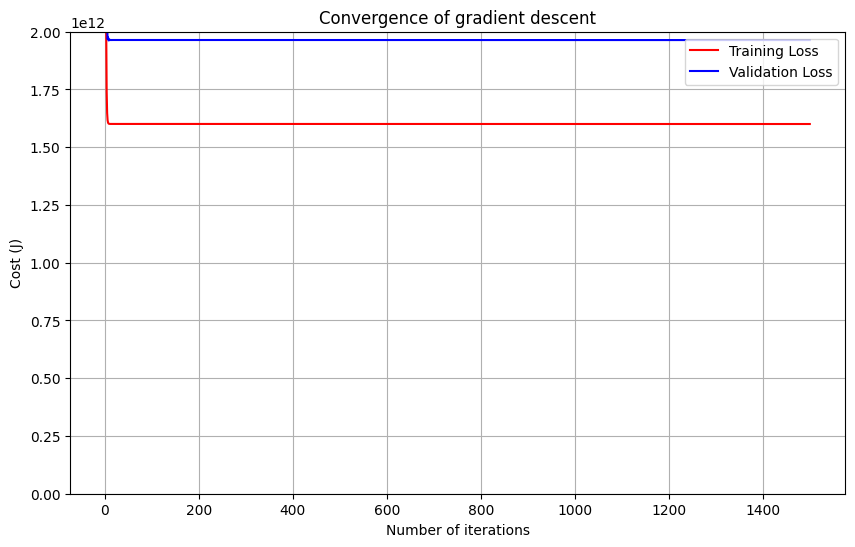

In [1089]:
# Area, bedrooms, bathrooms, stories, parking - No scaling
alpha = 0.00000005

theta = (np.zeros(6))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['parking']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['parking']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

theta = [ 26.65077272 857.77095622  97.91938191  56.68761625  89.21203271
  24.04126551  10.81299449  18.20144415   3.6503643   24.54394199
  20.56329015  11.97666512]
training loss history = [5.46108323e+12 2.88496280e+12 2.02797827e+12 ... 1.60046172e+12
 1.60046151e+12 1.60046130e+12]
validation loss history = [5.80409042e+12 3.08953599e+12 2.42623237e+12 ... 1.96381627e+12
 1.96381603e+12 1.96381579e+12]


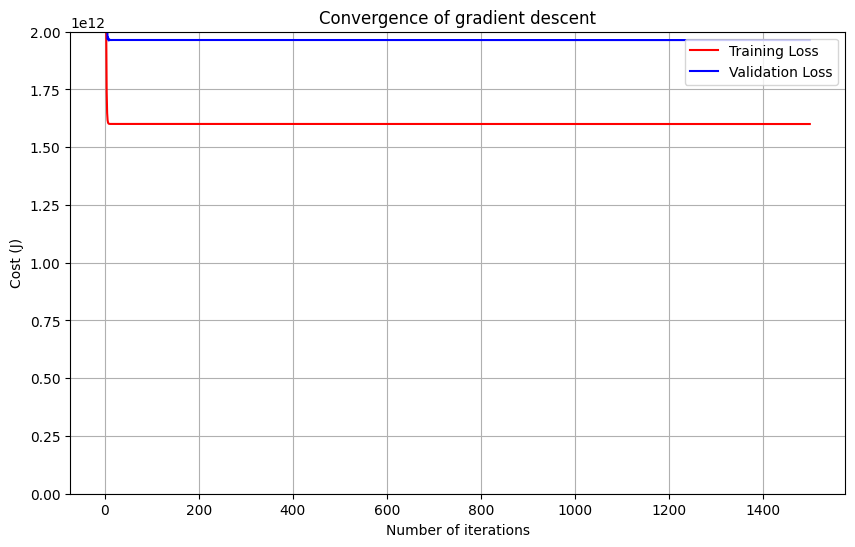

In [1090]:
# All except furnishing - No scaling
alpha = 0.00000005

theta = (np.zeros(12))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['mainroad'],
    X_n_train['guestroom'],
    X_n_train['basement'],
    X_n_train['hotwaterheating'],
    X_n_train['airconditioning'],
    X_n_train['parking'],
    X_n_train['prefarea']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['mainroad'],
    X_n_val['guestroom'],
    X_n_val['basement'],
    X_n_val['hotwaterheating'],
    X_n_val['airconditioning'],
    X_n_val['parking'],
    X_n_val['prefarea']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

In [1091]:
def input_normalize(x):
  return (x - x.min()) / (x.max() - x.min())

In [1092]:
X_n_train = {name: input_normalize(x).reshape(m, 1) for name, x in zip(names, X_raw_train)}
X_n_val   = {name: input_normalize(x).reshape(n, 1) for name, x in zip(names, X_raw_val)}

theta = [2298057.14628901 4719744.16720095  811114.05803554 3297233.5777904
 1672835.18883656 1058820.37496833]
training loss history = [1.01035417e+13 7.79759230e+12 6.08286847e+12 ... 7.29543745e+11
 7.29540406e+11 7.29537078e+11]
validation loss history = [9.67049444e+12 7.41739125e+12 5.75094267e+12 ... 1.68977090e+12
 1.68990288e+12 1.69003461e+12]


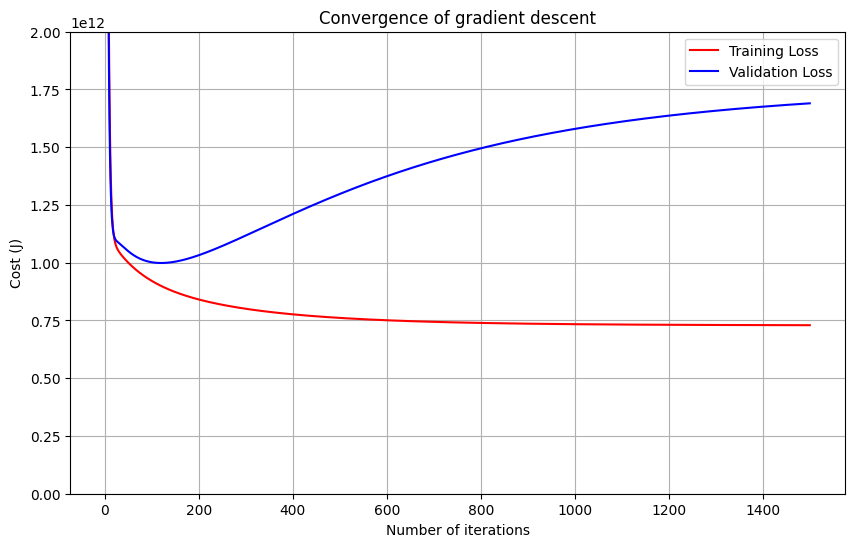

In [1093]:
# Area, bedrooms, bathrooms, stories, parking - Input normalization
alpha = 0.1

theta = (np.zeros(6))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['parking']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['parking']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

theta = [1703850.22758559 3478900.36240938  582010.70513157 2900103.21476935
 1424642.92695195  555002.9184244   301667.04792078  370657.71994102
 1007036.62309975  899718.22460983  790897.8266703   684493.46132194]
training loss history = [7.76451883e+12 4.73370229e+12 3.04405071e+12 ... 5.24391461e+11
 5.24388616e+11 5.24385779e+11]
validation loss history = [7.47401571e+12 4.57727194e+12 2.97946140e+12 ... 1.32512588e+12
 1.32522915e+12 1.32533223e+12]


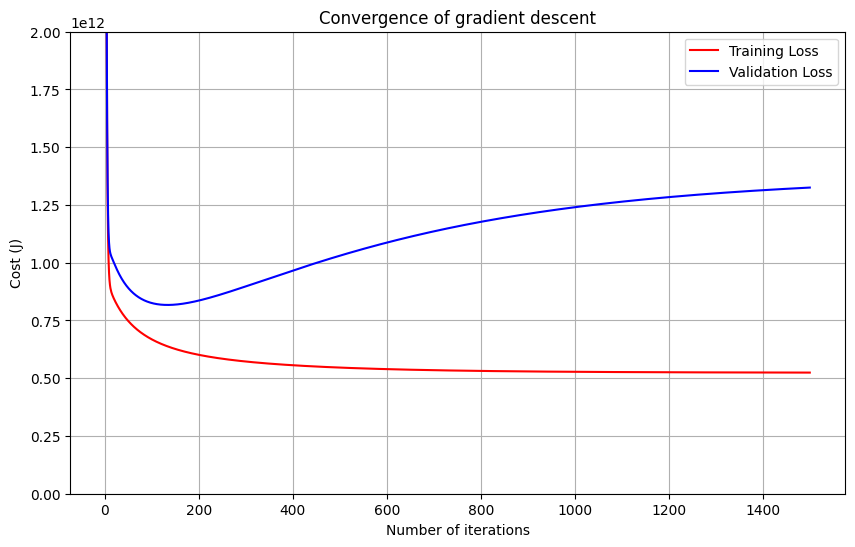

In [1094]:
# All except furnishing - Input normalization
alpha = 0.1

theta = (np.zeros(12))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['mainroad'],
    X_n_train['guestroom'],
    X_n_train['basement'],
    X_n_train['hotwaterheating'],
    X_n_train['airconditioning'],
    X_n_train['parking'],
    X_n_train['prefarea']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['mainroad'],
    X_n_val['guestroom'],
    X_n_val['basement'],
    X_n_val['hotwaterheating'],
    X_n_val['airconditioning'],
    X_n_val['parking'],
    X_n_val['prefarea']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

In [1095]:
def input_standardize(x):
  return (x - np.mean(x)) / np.std(x)

In [1096]:
X_n_train = {name: input_standardize(x).reshape(m, 1) for name, x in zip(names, X_raw_train)}
X_n_val   = {name: input_standardize(x).reshape(n, 1) for name, x in zip(names, X_raw_val)}

theta = [4789765.57339449  750663.57200193   86566.14505801  579574.73356455
  495831.21823859  289088.39092572]
training loss history = [1.06913347e+13 8.70753573e+12 7.13419759e+12 ... 7.28493947e+11
 7.28493947e+11 7.28493947e+11]
validation loss history = [1.02930926e+13 8.38116774e+12 6.86572356e+12 ... 9.24803026e+11
 9.24803026e+11 9.24803026e+11]


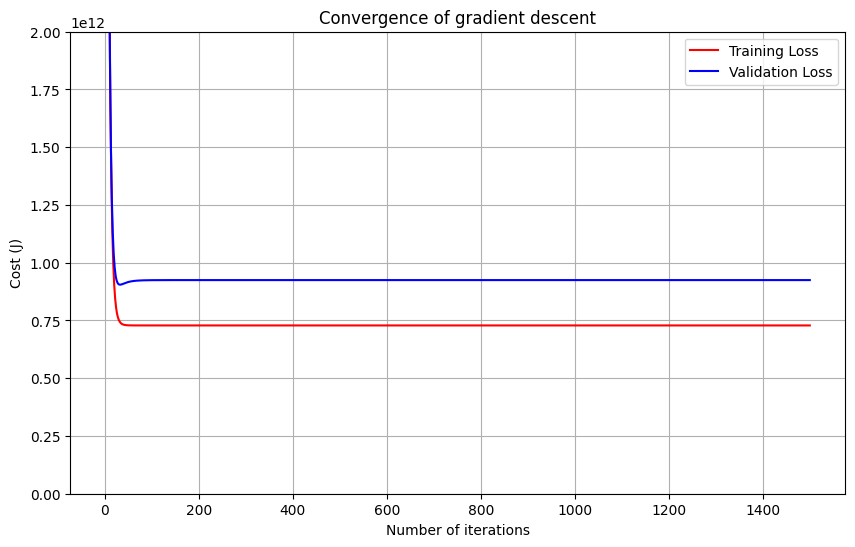

In [1097]:
# Area, bedrooms, bathrooms, stories, parking - Input standardization
alpha = 0.1

theta = (np.zeros(6))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['parking']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['parking']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

theta = [4789765.57339449  564889.59767775   51576.31449013  510709.73365738
  428396.62753765  182384.39677923  112065.95239869  183862.30188768
  209713.0210186   414567.45276104  215558.9009707   281918.07038285]
training loss history = [1.05327148e+13 8.48172827e+12 6.88540097e+12 ... 5.23389299e+11
 5.23389299e+11 5.23389299e+11]
validation loss history = [1.01598089e+13 8.19171230e+12 6.65779017e+12 ... 7.75368290e+11
 7.75368290e+11 7.75368290e+11]


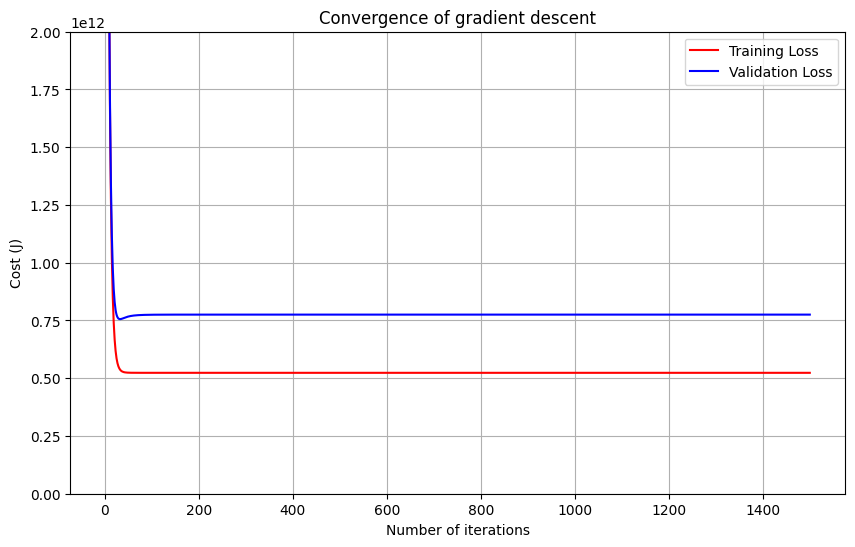

In [1098]:
# All except furnishing - Input standardization
alpha = 0.1

theta = (np.zeros(12))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['mainroad'],
    X_n_train['guestroom'],
    X_n_train['basement'],
    X_n_train['hotwaterheating'],
    X_n_train['airconditioning'],
    X_n_train['parking'],
    X_n_train['prefarea']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['mainroad'],
    X_n_val['guestroom'],
    X_n_val['basement'],
    X_n_val['hotwaterheating'],
    X_n_val['airconditioning'],
    X_n_val['parking'],
    X_n_val['prefarea']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

In [1099]:
def compute_cost(X, y, theta, lambda_):

  m = len(y)

  errors = X.dot(theta) - y
  reg = lambda_ / (2 * m) * np.sum(theta[1:] ** 2)
  J = 1 / (2 * m) * np.sum(errors ** 2) + reg

  return J

In [1100]:
def gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations, lambda_):

  m = len(y_train)
  training_costs = np.zeros(iterations)
  validation_costs = np.zeros(iterations)

  for i in range(iterations):
    errors = X_train.dot(theta) - y_train
    penalty = lambda_ * theta
    penalty[0] = 0
    sum_delta = (alpha / m) * (X_train.transpose().dot(errors) + penalty)
    theta = theta - sum_delta
    training_costs[i] = compute_cost(X_train, y_train, theta, lambda_)
    validation_costs[i] = compute_cost(X_val, y_val, theta, 0)

  return theta, training_costs, validation_costs

theta = [4789765.57339449  678986.52231475  123917.4095415   533195.85765883
  448648.96281645  289547.80840773]
training loss history = [1.06934545e+13 8.71715061e+12 7.15261217e+12 ... 7.93608822e+11
 7.93608822e+11 7.93608822e+11]
validation loss history = [1.02930926e+13 8.38367609e+12 6.87110590e+12 ... 9.15775393e+11
 9.15775393e+11 9.15775393e+11]


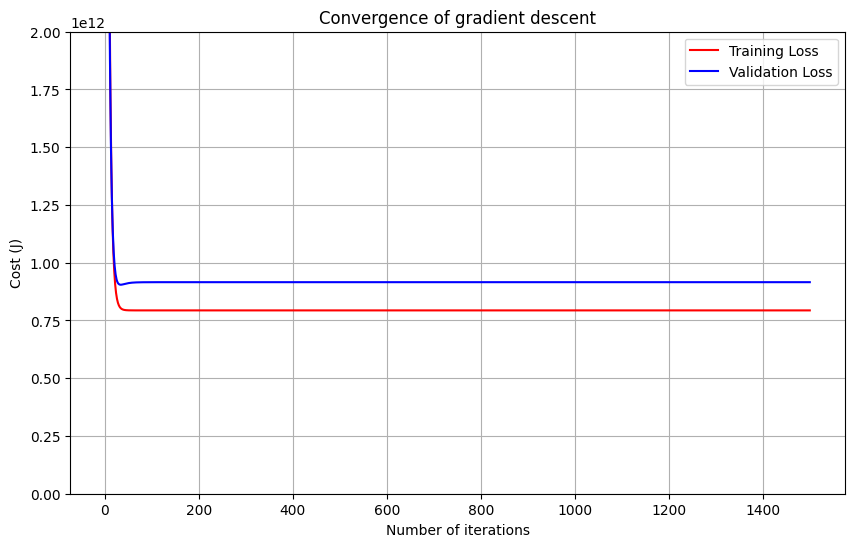

In [1105]:
# Area, bedrooms, bathrooms, stories, parking - Input standardization and parameters penalty
alpha = 0.1
lambda_ = 50

theta = (np.zeros(6))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['parking']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['parking']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations, lambda_)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)

theta = [4789765.57339449  515717.44340279   90043.20624532  471848.83315563
  386292.84222247  185877.66552812  122460.01739386  163385.22108072
  185138.40962335  389118.03329268  220738.38213339  268101.14017846]
training loss history = [1.05359246e+13 8.49527655e+12 6.90973566e+12 ... 5.86657838e+11
 5.86657838e+11 5.86657838e+11]
validation loss history = [1.01598089e+13 8.19502610e+12 6.66426115e+12 ... 7.62954748e+11
 7.62954748e+11 7.62954748e+11]


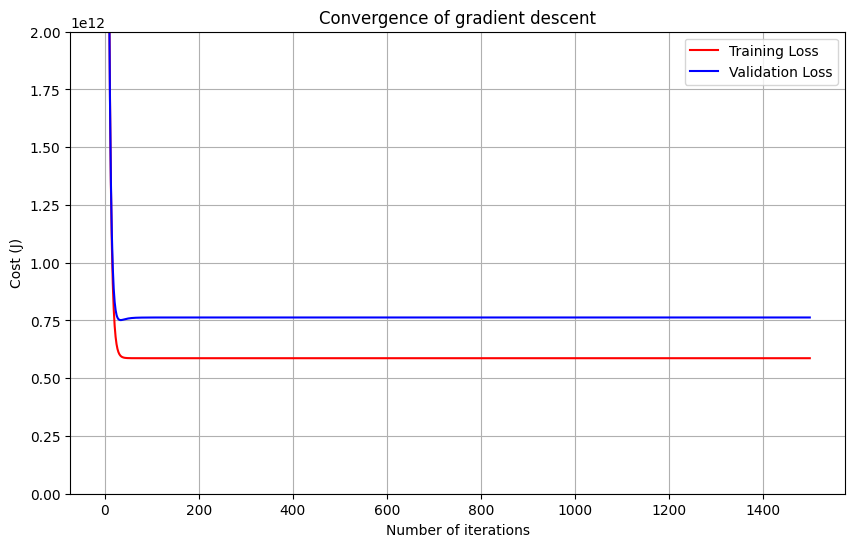

In [1106]:
# All except furnishing - Input standardization and parameters penalty
alpha = 0.1
lambda_ = 50

theta = (np.zeros(12))
X_train = np.hstack((
    X_0_train,
    X_n_train['area'],
    X_n_train['bedrooms'],
    X_n_train['bathrooms'],
    X_n_train['stories'],
    X_n_train['mainroad'],
    X_n_train['guestroom'],
    X_n_train['basement'],
    X_n_train['hotwaterheating'],
    X_n_train['airconditioning'],
    X_n_train['parking'],
    X_n_train['prefarea']
))
X_val = np.hstack((
    X_0_val,
    X_n_val['area'],
    X_n_val['bedrooms'],
    X_n_val['bathrooms'],
    X_n_val['stories'],
    X_n_val['mainroad'],
    X_n_val['guestroom'],
    X_n_val['basement'],
    X_n_val['hotwaterheating'],
    X_n_val['airconditioning'],
    X_n_val['parking'],
    X_n_val['prefarea']
))

theta, training_costs, validation_costs = gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations, lambda_)
print('theta =', theta)
print('training loss history =', training_costs)
print('validation loss history =', validation_costs)

convergence_plot(training_costs, validation_costs)